## DETR in `transformers`
In this notebook, we going through a simple example of using pretrained `detr-resnet-50` to detect some objects in an image.

In [1]:
%pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 38.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
# this example is mainly from https://huggingface.co/facebook/detr-resnet-50

from transformers import DetrImageProcessor, DetrForObjectDetection
import torch
from PIL import Image, ImageDraw
import requests

In [3]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

### Model
We are using `facebook/detr-resnet-50`, which is a basic DETR with a relatively small ResNet backbone. It has 100 object queries, which mean it can detect a maximum of 100 objects.

In [4]:
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

### Processor
The processor converts the image into a dict with keys `pixel_values` and `pixel_mask`. The pixel values are usually transformed in a manner that matches the paper implementation, which may involve normalization, resizing, etc.

In [5]:
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
inputs = processor(images=image, return_tensors="pt")

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

### Outputs
The output of the model is of type `DetrObjectDetectionOutput`, which contains `logits`, `last_hidden_states`, `pred_boxes`, etc. <br>
The size of `logits` is `(batch size, n_object_queries, n_classes)`, which is used to determine the classes of the detections. This model has 100 object queries and 92 classes. The object queries that have low confidences in classes, or have a "no object" class are filtered out in the `post_process_object_detection` function. <br>
The size of `pred_boxes` is `(batch size, n_object_queries, box_dimensions)`, which is used to determine the location of the bounding box.

In [6]:
outputs = model(**inputs)

In [7]:
target_sizes = torch.tensor([image.size[::-1]])
results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.9)[0]

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
            f"Detected {model.config.id2label[label.item()]} with confidence "
            f"{round(score.item(), 3)} at location {box}"
    )

Detected remote with confidence 0.998 at location [40.16, 70.81, 175.55, 117.98]
Detected remote with confidence 0.996 at location [333.24, 72.55, 368.33, 187.66]
Detected couch with confidence 0.995 at location [-0.02, 1.15, 639.73, 473.76]
Detected cat with confidence 0.999 at location [13.24, 52.05, 314.02, 470.93]
Detected cat with confidence 0.999 at location [345.4, 23.85, 640.37, 368.72]


In [8]:
img_draw = ImageDraw.Draw(image)
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    img_draw.rectangle(((box[0], box[1]),(box[2], box[3])), outline='Red')
    img_draw.text((box[0], box[1]), model.config.id2label[label.item()], align ="left")

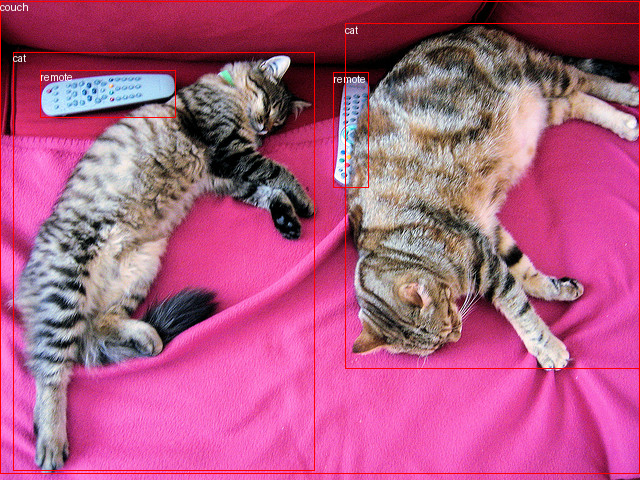

In [9]:
display(image)

Detected person with confidence 0.909 at location [189.57, 248.65, 202.06, 258.34]


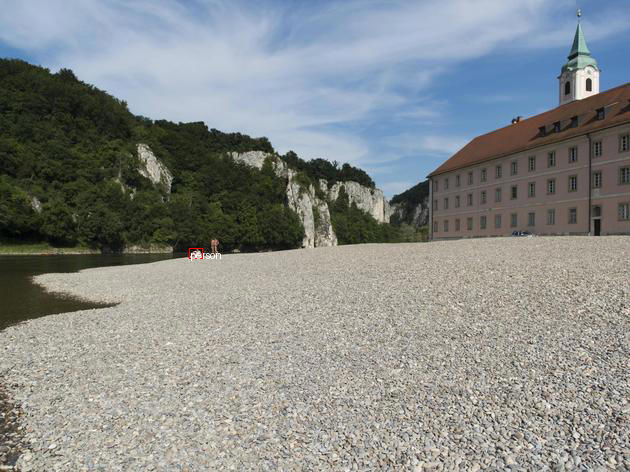

In [15]:
url2 = "https://img-s-msn-com.akamaized.net/tenant/amp/entityid/AA1Fr4ae.img?w=630&h=472&m=6"
image2 = Image.open(requests.get(url2, stream=True).raw)

inputs2 = processor(images=image2, return_tensors="pt")
outputs2 = model(**inputs2)

target_sizes = torch.tensor([image2.size[::-1]])
results = processor.post_process_object_detection(outputs2, target_sizes=target_sizes, threshold=0.9)[0]

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
            f"Detected {model.config.id2label[label.item()]} with confidence "
            f"{round(score.item(), 3)} at location {box}"
    )

img_draw2 = ImageDraw.Draw(image2)
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    img_draw2.rectangle(((box[0], box[1]),(box[2], box[3])), outline='Red')
    img_draw2.text((box[0], box[1]), model.config.id2label[label.item()], align ="left")

display(image2)